# Lab 3: Sentinel-1 Time Series for Crop Growth in Midwest Row-Crop Fields

This notebook is for a lab on seasonal crop growth using Sentinel-1 SAR backscatter in large Midwestern U.S. fields.

The lab is designed to stay fully in Google Earth Engine + Python. We will be:

- building a consistent Sentinel-1 time series,
- selecting individual row-crop fields, forested regions, and towns/cities,
- extracting field-scale backscatter statistics,
- comparing seasonal trajectories,
- proposing a simple crop growth metric based on VV, VH, or VV/VH.

---

## Lab concept

Students will:

1. choose several individual regions in a Midwest US AOI. You do not have to choose a midwest US AOI, but it will be the easiest. Midwest US/Canada has perfectly North/South Aligned farms in 1.5 km grids, which uniformly grow corn/wheat/soy/etc. European farms are much smaller, and randomly oriented. Averaging over an entire field will increase the signal to noise ratio.
2. define field polygons as regions of interest,
3. build a seasonal Sentinel-1 time series,
4. compute field-level summary statistics for:
   - VV
   - VH
   - VV - VH (in dB is a convenient proxy related to VV/VH ratio)
5. interpret how those quantities evolve from:
   - bare ground / early season
   - vegetative growth
   - maturity
   - senescence (interesting fact - senescence progression is monitored via NDVI)
   - harvest

---

## Why the Midwest U.S.?

This is a good teaching region because many fields are:

- large,
- homogeneous,
- easy to outline,
- minimally affected by complex topography,
- dominated by row crops with strong seasonal structure.

That makes field-scale SAR time series much easier to interpret than small, irregular fields. Irregularly oriented fields produce an additional complexity with regards to geometry. You may have noticed when exploring Krakow SAR that the backscatter from farms could vary greatly. This can be due to differences in crop type, but it can also be related to how the rows are oriented with respect to the satellite look direction. Think about the ground texture of farms, there are many small ridges and valleys. If these ridges and valleys are parallel to the satellite look direction, backscatter will be weaker, and if the ridges and valleys are perpendicular to the satellite look direction, backscatter will be stronger.

---

## Learning goals

By the end of this lab, students should be able to:

- explain why SAR time series must be filtered consistently,
- compute a field-averaged VV and VH time series,
- compare crop fields with a non-crop control,
- propose and defend simple crop growth metrics,
- explain why VH or VV-VH may respond differently from VV alone.

---

## 1. Imports and Earth Engine initialization

This notebook assumes that students already have:

- a working Python environment,
- the Earth Engine Python API,
- `geemap`,
- libraries `matplotlib` and `pandas`.

In [1]:
import ee
import geemap
import pandas as pd
import json
import matplotlib.pyplot as plt

PROJECT_ID = "river-dynamo-494108-u6"

try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

print("Earth Engine initialized.")

Earth Engine initialized.


## 2. Define an agricultural AOI

This notebook starts with a large AOI in northern Iowa / southern Minnesota.  
You can adjust it later, but it is helpful to begin with a region dominated by large row-crop fields. In one scene, I want you to find a place that has:

- individual crop fields that you can isolate
- A city or town that we're not expecting a strong vegetative growth signal from
- a stand of trees you can isolate

**QUESTION (5pts): Why is the subregion you chose a good choice for exploring crop growth? Trees and crops both have vegetative growth during summer months, but what differences would you expect to see over a year, with regards to VV, VH, and VV-VH? What do you expect to see in the city or town that you have isolated?**

**ANSWER:**

 - Why is the subregion you chose a good choice for exploring crop growth?

As was mentioned in the intro to the lab, area of northern Iowa / southern Minnesota has large fields that are big some exactly rectangular on axes of north and south. I chose three such fields and one of the has perpendicular rows to the different to, to notice some difference in backscatter.

- Trees and crops both have vegetative growth during summer months, but what differences would you expect to see over a year, with regards to VV, VH, and VV-VH?

I expect to see some significant backscatter from trees even in winter months, because of trees structure. During winter months, I expect low backscatter from bare fields, so basically bare soil. In general, trees -> lower differences between VV, VH backscatter, and VV-VH over a year than crops.

- What do you expect to see in the city or town that you have isolated?

I expect to see differences in backscatter only in green areas and roughly the same backscatter for building areas.

In [2]:
# Example AOI: large row-crop region in northern Iowa / southern Minnesota
aoi = ee.Geometry.Rectangle([-93.95, 43.65, -93.25, 44.15])

aoi_trees = ee.Geometry.Rectangle([-93.81393, 43.86132, -93.80792, 43.85824])
aoi_field_1 = ee.Geometry.Rectangle([-93.81493, 43.84368, -93.80792, 43.83327])
aoi_field_2 = ee.Geometry.Rectangle([-93.79770, 43.87328, -93.78823, 43.86989])
aoi_field_3 = ee.Geometry.Rectangle([-93.76444, 43.88411, -93.76129, 43.87701])
aoi_city = ee.Geometry.Rectangle([-93.50694, 44.08000, -93.49697, 44.06647])

# Growing season year
YEAR = 2025

# Visualization parameters
vv_vis = {"min": -18, "max": 2}
vh_vis = {"min": -28, "max": -8}
ratio_vis = {"min": 2, "max": 12}

m_field_1 = geemap.Map(center=[43.9, -93.6], zoom=10)
m_field_1.addLayer(aoi, {"color": "red"}, "AOI")
m_field_1.addLayer(aoi_trees, {"color": "green"}, "AOI_Trees")
m_field_1.addLayer(aoi_field_1, {"color": "yellow"}, "AOI_Field_1")
m_field_1.addLayer(aoi_field_2, {"color": "orange"}, "AOI_Field_2")
m_field_1.addLayer(aoi_field_3, {"color": "purple"}, "AOI_Field_3")
m_field_1.addLayer(aoi_city, {"color": "gray"}, "AOI_City")
m_field_1

Map(center=[43.9, -93.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## 3. Helper functions

To keep the notebook readable, the repetitive Earth Engine logic is collected into helper functions.

These functions do most of the work for:

- building a filtered Sentinel-1 collection,
- creating monthly composites,
- computing a convenient VV-VH metric,
- extracting region statistics through time.

---

### Why use `VV - VH` here?

Sentinel-1 GRD backscatter in Earth Engine is in dB.  
So for this lab, instead of using a raw linear ratio `VV/VH`, we use:

$$
VV - VH
$$

because in dB space this is directly related to the log-ratio and is easier to interpret consistently alongside VV and VH.


In [3]:
def get_s1_collection(start_date, end_date, region=aoi,
                      orbit_pass="ASCENDING",
                      mode="IW",
                      resolution=10):
    """Return a filtered Sentinel-1 GRD collection with VV and VH."""
    collection = (
        ee.ImageCollection("COPERNICUS/S1_GRD")
        .filterBounds(region)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq("instrumentMode", mode))
        .filter(ee.Filter.eq("orbitProperties_pass", orbit_pass))
        .filter(ee.Filter.eq("resolution_meters", resolution))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
        .select(["VV", "VH"])
    )
    return collection


def monthly_composite(year, month, region=aoi):
    """Return a monthly median Sentinel-1 image with a derived VV-VH band."""
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, "month")

    collection = get_s1_collection(start, end, region=region)
    image = collection.median().clip(region)

    vv_minus_vh = image.select("VV").subtract(image.select("VH")).rename("VV_minus_VH")

    return (
        image.addBands(vv_minus_vh)
        .set({
            "year": year,
            "month": month,
            "system:time_start": start.millis(),
            "scene_count": collection.size()
        })
    )


def build_monthly_stack(year, months=range(3, 11), region=aoi):
    """Create a monthly ImageCollection for a growing season."""
    images = [monthly_composite(year, month, region=region) for month in months]
    return ee.ImageCollection(images)


def region_time_series(image_collection, region, scale=10):
    """Extract field-level mean VV, VH, and VV_minus_VH through time.

    Accepts either an ee.Geometry or an ee.Feature.
    """
    # If region is a Feature, convert it to its geometry
    if isinstance(region, ee.feature.Feature):
        region = region.geometry()

    def per_image(img):
        stats = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region,
            scale=scale,
            maxPixels=1e9,
            bestEffort=True
        )
        return ee.Feature(None, {
            "date": ee.Date(img.get("system:time_start")).format("YYYY-MM-dd"),
            "year": img.get("year"),
            "month": img.get("month"),
            "scene_count": img.get("scene_count"),
            "VV": stats.get("VV"),
            "VH": stats.get("VH"),
            "VV_minus_VH": stats.get("VV_minus_VH")
        })

    return ee.FeatureCollection(image_collection.map(per_image))

def fc_to_df(fc):
    """Convert an Earth Engine FeatureCollection of stats into a pandas DataFrame."""
    data = fc.getInfo()["features"]
    rows = [f["properties"] for f in data]
    df = pd.DataFrame(rows)
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])
        df = df.sort_values("date").reset_index(drop=True)
    return df


## 4. Build a seasonal Sentinel-1 time series

We build monthly median images from February through November.

**QUESTION (5pts): What are the advantages and disadvantages of using monthly median stacks instead of relying on single scenes? In what circumstances would you not want to do any temporal averaging, and instead rely on single scenes?**

**ANSWER:**

In signal processing we can denoise signals by averaging them, so because of this, using monthly median stack, can eliminate some errors, outliers and other data noise. But reducing temporal resolution is big disadvantage when we are observing some time sensitive changes, like for example crop growth. Then we loose temporal data, which might be important for our models etc. So for example, for crop monitoring that could help precision farming, I would rely on single scenes always.

**QUESTION (5pts): Why do we filter Sentinel-1 by orbit direction, instrument mode, polarization, and resolution before building the time series? What might happen if ascending and descending passes were mixed in the same time series?**

**ANSWER:**

We want to keep the time series consistent. Orbit direction, instrument mode, polarization, and resolution all affect backscatter from the point of data, and not from the point of what we're observing. For example orbit direction changes the whole geometry of looking of the field, because it's looking from different side and it would be unacceptable to create a time series from mixed orbit direction pictures.


In [4]:
months = list(range(2, 12))  # February through November
monthly_stack = build_monthly_stack(YEAR, months=months, region=aoi)
monthly_stack_trees = build_monthly_stack(YEAR, months=months, region=aoi_trees)
monthly_stack_field_1 = build_monthly_stack(YEAR, months=months, region=aoi_field_1)
monthly_stack_field_2 = build_monthly_stack(YEAR, months=months, region=aoi_field_2)
monthly_stack_field_3 = build_monthly_stack(YEAR, months=months, region=aoi_field_3)
monthly_stack_city = build_monthly_stack(YEAR, months=months, region=aoi_city)

print("Monthly images in stack for trees:", monthly_stack_trees.size().getInfo())
print("Monthly images in stack for field:", monthly_stack_field_1.size().getInfo())
print("Monthly images in stack for city:", monthly_stack_city.size().getInfo())

# Check how many scenes contribute to each month
for month in months:
    img_trees = monthly_composite(YEAR, month, aoi_trees)
    img_field_1 = monthly_composite(YEAR, month, aoi_field_1)
    img_field_2 = monthly_composite(YEAR, month, aoi_field_2)
    img_field_3 = monthly_composite(YEAR, month, aoi_field_3)
    img_city = monthly_composite(YEAR, month, aoi_city)
    print(f"[TREES] Month {month:02d}: {ee.Number(img_trees.get('scene_count')).getInfo()} scenes")
    print(f"[FIELD] Month {month:02d}: {ee.Number(img_field_1.get('scene_count')).getInfo()} scenes")
    print(f"[CITY] Month {month:02d}: {ee.Number(img_city.get('scene_count')).getInfo()} scenes")


Monthly images in stack for trees: 10
Monthly images in stack for field: 10
Monthly images in stack for city: 10
[TREES] Month 02: 5 scenes
[FIELD] Month 02: 5 scenes
[CITY] Month 02: 5 scenes
[TREES] Month 03: 6 scenes
[FIELD] Month 03: 6 scenes
[CITY] Month 03: 6 scenes
[TREES] Month 04: 7 scenes
[FIELD] Month 04: 7 scenes
[CITY] Month 04: 7 scenes
[TREES] Month 05: 4 scenes
[FIELD] Month 05: 4 scenes
[CITY] Month 05: 4 scenes
[TREES] Month 06: 3 scenes
[FIELD] Month 06: 3 scenes
[CITY] Month 06: 3 scenes
[TREES] Month 07: 3 scenes
[FIELD] Month 07: 3 scenes
[CITY] Month 07: 3 scenes
[TREES] Month 08: 4 scenes
[FIELD] Month 08: 4 scenes
[CITY] Month 08: 4 scenes
[TREES] Month 09: 2 scenes
[FIELD] Month 09: 2 scenes
[CITY] Month 09: 2 scenes
[TREES] Month 10: 4 scenes
[FIELD] Month 10: 4 scenes
[CITY] Month 10: 4 scenes
[TREES] Month 11: 4 scenes
[FIELD] Month 11: 4 scenes
[CITY] Month 11: 4 scenes


## 5. Quick visual inspection

Before drawing fields, it is useful to inspect one or two monthly composites.

Suggested things to look for:

- field texture,
- strong contrasts between different fields,
- stable non-crop controls such as roads, towns, or tree patches.

**QUESTION (10pts): Compare an early month with a peak month visually. Feel free to change the months plotted, or add in comparisons of early vs mid- season VV_minus_VH, for your investigations. Take particular note of how much VH changes vs how much VV changes. What regions do you think you will choose for your ROI's and why? If you want an extra challenge (but not necessary), try to find a field you think was tall crops, a field you think was short crops, and a field you think was left barren.**

**ANSWER:**

At this point, I already chose my ROIs. But in general, for both VV and VH backscatter difference between February and uly is huge, with water staying very consistent, trees and cities being rather consistent. We ca easily see where some seasonal growth is happening. I still think that I chose good regions. Also VV - VH maps confirm that regions behave mostly as expected, so where there is crop growth, there is large decrease in VV - VH, which is expected, because VH is betting stronger because of vegetation and thus structure. 


In [12]:
img_whole_early = monthly_composite(YEAR, 2, aoi)
img_whole_peak = monthly_composite(YEAR, 7, aoi)

img_field_1_early = monthly_composite(YEAR, 2, aoi_field_1)
img_field_1_peak = monthly_composite(YEAR, 7, aoi_field_1)

img_field_2_early = monthly_composite(YEAR, 2, aoi_field_2)
img_field_2_peak = monthly_composite(YEAR, 7, aoi_field_2)

img_field_3_early = monthly_composite(YEAR, 2, aoi_field_3)
img_field_3_peak = monthly_composite(YEAR, 7, aoi_field_3)

img_trees_early = monthly_composite(YEAR, 2, aoi_trees)
img_trees_peak = monthly_composite(YEAR, 7, aoi_trees)

img_city_early = monthly_composite(YEAR, 2, aoi_city)
img_city_peak = monthly_composite(YEAR, 7, aoi_city)

#YOUR CODE HERE: The lines above grab the montlhy composite images for February and July. I want you to plot a split_map image of the VH channel in this cell, and in the cell below plot a split_map image of the VV channel for the same months.

def plot_split_map(left_img, right_img, band, vis_params, title_left, title_right, center=[43.9, -93.6], zoom=11):
    m = geemap.Map(center=center, zoom=zoom)
    m.split_map(
        left_layer=geemap.ee_tile_layer(left_img.select(band), vis_params, title_left),
        right_layer=geemap.ee_tile_layer(right_img.select(band), vis_params, title_right)
    )
    m.d
    display(m)

# Whole AOI
plot_split_map(
    img_whole_early, img_whole_peak,
    "VH", vh_vis,
    "VH February", "VH July"
)

# Field 1
plot_split_map(
    img_field_1_early, img_field_1_peak,
    "VH", vh_vis,
    "Field 1 VH February", "Field 1 VH July"
)

# Field 2
plot_split_map(
    img_field_2_early, img_field_2_peak,
    "VH", vh_vis,
    "Field 2 VH February", "Field 2 VH July"
)

# Field 3
plot_split_map(
    img_field_3_early, img_field_3_peak,
    "VH", vh_vis,
    "Field 3 VH February", "Field 3 VH July"
)

# City / control region
plot_split_map(
    img_city_early, img_city_peak,
    "VH", vh_vis,
    "City VH February", "City VH July"
)

# Trees / stable vegetation comparison
plot_split_map(
    img_trees_early, img_trees_peak,
    "VH", vh_vis,
    "Trees VH February", "Trees VH July"
)

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

In [13]:
# February vs July VV comparison

# Whole AOI
plot_split_map(
    img_whole_early, img_whole_peak,
    "VV", vv_vis,
    "VV February", "VV July"
)

# Field 1
plot_split_map(
    img_field_1_early, img_field_1_peak,
    "VV", vv_vis,
    "Field 1 VV February", "Field 1 VV July"
)

# Field 2
plot_split_map(
    img_field_2_early, img_field_2_peak,
    "VV", vv_vis,
    "Field 2 VV February", "Field 2 VV July"
)

# Field 3
plot_split_map(
    img_field_3_early, img_field_3_peak,
    "VV", vv_vis,
    "Field 3 VV February", "Field 3 VV July"
)

# City / control region
plot_split_map(
    img_city_early, img_city_peak,
    "VV", vv_vis,
    "City VV February", "City VV July"
)

# Trees / stable vegetation comparison
plot_split_map(
    img_trees_early, img_trees_peak,
    "VV", vv_vis,
    "Trees VV February", "Trees VV July"
)

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

In [14]:
# February vs July VV - VH comparison

vv_minus_vh_vis = {
    "min": 0,
    "max": 15,
    "palette": ["blue", "white", "red"]
}

# Whole AOI
plot_split_map(
    img_whole_early, img_whole_peak,
    "VV_minus_VH", vv_minus_vh_vis,
    "VV - VH February", "VV - VH July"
)

# Field 1
plot_split_map(
    img_field_1_early, img_field_1_peak,
    "VV_minus_VH", vv_minus_vh_vis,
    "Field 1 VV - VH February", "Field 1 VV - VH July"
)

# Field 2
plot_split_map(
    img_field_2_early, img_field_2_peak,
    "VV_minus_VH", vv_minus_vh_vis,
    "Field 2 VV - VH February", "Field 2 VV - VH July"
)

# Field 3
plot_split_map(
    img_field_3_early, img_field_3_peak,
    "VV_minus_VH", vv_minus_vh_vis,
    "Field 3 VV - VH February", "Field 3 VV - VH July"
)

# City / control region
plot_split_map(
    img_city_early, img_city_peak,
    "VV_minus_VH", vv_minus_vh_vis,
    "City VV - VH February", "City VV - VH July"
)

# Trees / stable vegetation comparison
plot_split_map(
    img_trees_early, img_trees_peak,
    "VV_minus_VH", vv_minus_vh_vis,
    "Trees VV - VH February", "Trees VV - VH July"
)

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

# 6. Draw field polygons

Use the map drawing tools to create several polygons:

- at least **two different crop fields**
- at least **two control areas** (1 patch of trees, 1 city or town)

### Suggested strategy
Pick fields that are:

- large,
- internally uniform,
- clearly separated from neighboring fields.

After drawing polygons on the map, export them to Earth Engine objects.

**NOTE: You will need to remember the order of the ROI's you chose. For example, remember that you first chose three farm fields, then a tree stand, then the city/town. In the next section, you will need to assign these drawn features to variables and a dictionary.**



In [17]:
m_field_1 = geemap.Map(center=[43.9, -93.6], zoom=12)
m_field_1.addLayer(img_field_1_peak.select("VV"), vv_vis, "VV July")
m_field_1.addLayer(img_field_1_peak.select("VH"), vh_vis, "VH July")
#m.addLayer(aoi, {"color": "red"}, "AOI")
m_field_1

# After drawing polygons with the map tools, use:
drawn_fc = m_field_1.draw_features

In [19]:
drawn_fc = m_field_1.draw_features
print(drawn_fc)

[]


## 7. Make sure your drawn features are where you want them.

To do this, you will need to need to adjust the code below to match the order and number of ROI's you chose to investigate.


In [21]:
roi_dict = {
    "Field_1": aoi_field_1,
    "Field_2": aoi_field_2,
    "Field_3": aoi_field_3,
    "Trees_1": aoi_trees,
    "Control_1": aoi_city
}

m_field_1 = geemap.Map(center=[43.9, -93.6], zoom=12)
m_field_1.addLayer(img_whole_peak.select("VV"), vv_vis, "VV July")
for name, geom in roi_dict.items():
    m_field_1.addLayer(geom, {"color": "yellow"}, name)
m_field_1

##PLEASE PASTE THE OUTPUT OF THIS AS A COMMENT HERE SO THAT I KNOW WHICH ROI's YOU CHOSE
for name, roi in roi_dict.items():
    print(name, roi.getInfo())

# Field_1 {'type': 'Polygon', 'coordinates': [[[-93.81493, 43.83327], [-93.80792, 43.83327], [-93.80792, 43.84368], [-93.81493, 43.84368], [-93.81493, 43.83327]]]}
# Field_2 {'type': 'Polygon', 'coordinates': [[[-93.7977, 43.86989], [-93.78823, 43.86989], [-93.78823, 43.87328], [-93.7977, 43.87328], [-93.7977, 43.86989]]]}
# Field_3 {'type': 'Polygon', 'coordinates': [[[-93.76444, 43.87701], [-93.76129, 43.87701], [-93.76129, 43.88411], [-93.76444, 43.88411], [-93.76444, 43.87701]]]}
# Trees_1 {'type': 'Polygon', 'coordinates': [[[-93.81393, 43.85824], [-93.80792, 43.85824], [-93.80792, 43.86132], [-93.81393, 43.86132], [-93.81393, 43.85824]]]}
# Control_1 {'type': 'Polygon', 'coordinates': [[[-93.50694, 44.06647], [-93.49697, 44.06647], [-93.49697, 44.08], [-93.50694, 44.08], [-93.50694, 44.06647]]]}


Field_1 {'type': 'Polygon', 'coordinates': [[[-93.81493, 43.83327], [-93.80792, 43.83327], [-93.80792, 43.84368], [-93.81493, 43.84368], [-93.81493, 43.83327]]]}
Field_2 {'type': 'Polygon', 'coordinates': [[[-93.7977, 43.86989], [-93.78823, 43.86989], [-93.78823, 43.87328], [-93.7977, 43.87328], [-93.7977, 43.86989]]]}
Field_3 {'type': 'Polygon', 'coordinates': [[[-93.76444, 43.87701], [-93.76129, 43.87701], [-93.76129, 43.88411], [-93.76444, 43.88411], [-93.76444, 43.87701]]]}
Trees_1 {'type': 'Polygon', 'coordinates': [[[-93.81393, 43.85824], [-93.80792, 43.85824], [-93.80792, 43.86132], [-93.81393, 43.86132], [-93.81393, 43.85824]]]}
Control_1 {'type': 'Polygon', 'coordinates': [[[-93.50694, 44.06647], [-93.49697, 44.06647], [-93.49697, 44.08], [-93.50694, 44.08], [-93.50694, 44.06647]]]}


## 8. Extract time series for each field

For each ROI, compute a field-mean time series of:

- VV
- VH
- VV - VH

This is the core analysis step of the lab.

In [22]:
ts_dict = {}

for name, geom in roi_dict.items():
    fc = region_time_series(monthly_stack, geom, scale=10)
    df = fc_to_df(fc)
    ts_dict[name] = df

ts_dict["Field_1"]


,VH,VV,VV_minus_VH,date,month,scene_count,year
0,-30.824688,-16.118414,14.706274,2025-02-01,2,8,2025
1,-22.433620,-12.067149,10.366471,2025-03-01,3,8,2025
2,-24.833341,-12.367669,12.465672,2025-04-01,4,10,2025
3,-27.708116,-13.970803,13.737313,2025-05-01,5,4,2025
4,-22.580578,-11.020167,11.560411,2025-06-01,6,3,2025
5,-16.813493,-9.596605,7.216888,2025-07-01,7,3,2025
6,-17.248060,-9.916207,7.331853,2025-08-01,8,4,2025
7,-15.878051,-8.722002,7.156049,2025-09-01,9,2,2025
8,-27.039984,-14.826323,12.213661,2025-10-01,10,4,2025
9,-24.447542,-12.605528,11.842014,2025-11-01,11,4,2025


**QUESTION (5pts): Which month has the minimum VH? Which month has the maximum VH? Does this match what you expected from the image comparison?**

**ANSWER:**

February has the minimum VH and July has the maximum VH, which is something that I expected. 


## 9. Plot VV, VH, and VV-VH through time

These plots are where the crop-growth story should begin to emerge.

**QUESTION (20pts):**
- Qualitatively compare your three different types of ROI's (1) farms; (2) trees; and (3) towns. A few sentences to a short paragraph is enough.
- Based on these plots, identify the months that (1) crops started growing; (2) crops stopped growing; and (3) crops were harvested.
- Does VV-VH separate crops from control AOI's better than VV alone?
- Which ROI looks least like an actively growing crop field?
- Which ROI shows the strongest seasonal change in VH? Which ROI is most stable through time? Explain whether each behavior is more consistent with crop growth, forest canopy, or built-up land.

**ANSWER:**

- Qualitatively compare your three different types of ROI's (1) farms; (2) trees; and (3) towns. A few sentences to a short paragraph is enough.

We can see that VV, VH, VV - VH are somehow stable for trees and city, which is something that I would expect. We can see that fields are indeed changing very much through time, and we can see a huge growing in May, which would make sense, as this is the most important month usually for the crop growth on the Northern hemisphere. In general, those plots match my predictions and observations.

- Based on these plots, identify the months that (1) crops started growing; (2) crops stopped growing; and (3) crops were harvested.

It seems that crops started growing substantially in May and they were harvested in September.
 
- Does VV-VH separate crops from control AOI's better than VV alone?

I wouldn't say so. I would say that they separate crops from control with the same level of confidence, at least based on the plots.

- Which ROI looks least like an actively growing crop field?

I would say that field 2 that I chose is the least actively growing crop field with the smallest differences in backscatter and VV - VH.

- Which ROI shows the strongest seasonal change in VH? Which ROI is most stable through time? Explain whether each behavior is more consistent with crop growth, forest canopy, or built-up land.

Strongest seasonal change can be observed on field 3. The most stable ROI is control ROI which is a city. In general: crop growth -> big seasonal changes, forest canopy and built-up land, small seasonal changes.


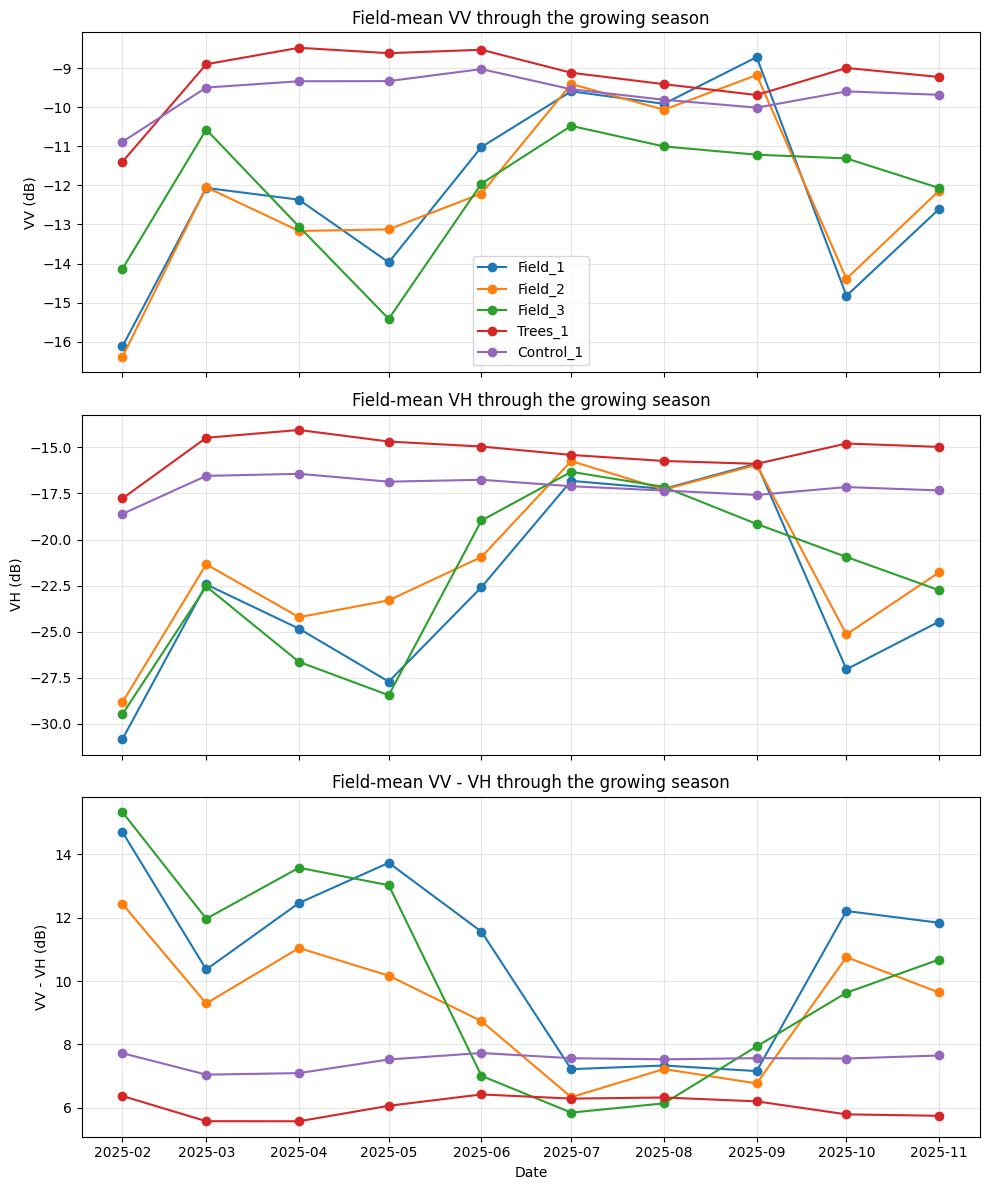

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for name, df in ts_dict.items():
    axes[0].plot(df["date"], df["VV"], marker="o", label=name)
    axes[1].plot(df["date"], df["VH"], marker="o", label=name)
    axes[2].plot(df["date"], df["VV_minus_VH"], marker="o", label=name)

axes[0].set_title("Field-mean VV through the growing season")
axes[0].set_ylabel("VV (dB)")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Field-mean VH through the growing season")
axes[1].set_ylabel("VH (dB)")
axes[1].grid(True, alpha=0.3)

axes[2].set_title("Field-mean VV - VH through the growing season")
axes[2].set_ylabel("VV - VH (dB)")
axes[2].set_xlabel("Date")
axes[2].grid(True, alpha=0.3)

axes[0].legend()
plt.tight_layout()
plt.show()


## 10. Build a simple crop-growth metric

Next I want you to propose a metric that captures crop development.

Possible first ideas include:

- peak VH minus spring VH,
- July VH minus April VH,
- maximum seasonal VV-VH range,
- cumulative increase from planting to peak growth.

Below is one simple example:

\[
Growth Metric = VH_{peak} - VH_{early}
\]

This is not necessarily the best metric — it is just a starting point.



In [24]:
##YOUR CODE HERE (50pts)
# Simple crop growth metric:
# Growth Metric = max VH during growing season - early season VH

early_month = 4
growing_months = [4, 5, 6, 7, 8]

growth_metrics = {}

for roi_name, roi in roi_dict.items():
    vh_values = []

    for month in growing_months:
        img = monthly_composite(YEAR, month, roi)

        mean_vh = img.select("VH").reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=roi,
            scale=10,
            maxPixels=1e9
        ).get("VH")

        vh_values.append(ee.Number(mean_vh))

    vh_early = vh_values[0]
    vh_peak = ee.List(vh_values).reduce(ee.Reducer.max())

    growth_metric = ee.Number(vh_peak).subtract(vh_early)

    growth_metrics[roi_name] = growth_metric

for roi_name, metric in growth_metrics.items():
    print(roi_name, metric.getInfo())

Field_1 8.01984785194125
Field_2 8.471409887598499
Field_3 10.313831571042943
Trees_1 0
Control_1 0


In [26]:
# -------------------------------------------------------------------
# Metric: Seasonal Radar Vegetation Growth Index
#
# Growth Metric = max(RVI from Apr-Aug) - RVI in April
#
# RVI = 4 * VH_linear / (VV_linear + VH_linear)
#
# Note: Sentinel-1 backscatter in this notebook is in dB,
# so we first convert VV and VH from dB to linear scale.
# -------------------------------------------------------------------

def add_rvi(img):
    """
    Add a dual-pol Radar Vegetation Index band to a Sentinel-1 image.

    RVI = 4 * VH_linear / (VV_linear + VH_linear)

    VV and VH are assumed to be in dB, so they are converted to linear scale.
    """

    vv_db = img.select("VV")
    vh_db = img.select("VH")

    vv_lin = ee.Image(10).pow(vv_db.divide(10))
    vh_lin = ee.Image(10).pow(vh_db.divide(10))

    rvi = vh_lin.multiply(4).divide(vv_lin.add(vh_lin)).rename("RVI")

    return img.addBands(rvi)


def mean_band_for_roi(img, band_name, roi):
    """
    Compute mean value of a selected band inside one ROI.
    """

    value = img.select(band_name).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=10,
        maxPixels=1e9
    ).get(band_name)

    return ee.Number(value)


# Months used for crop-growth analysis
early_month = 4
growing_months = [4, 5, 6, 7, 8]

growth_results = {}

for roi_name, roi in roi_dict.items():

    monthly_rvi_values = []

    for month in growing_months:

        # Build monthly composite
        img = monthly_composite(YEAR, month, roi)

        # Add RVI band
        img = add_rvi(img)

        # Mean RVI inside ROI
        mean_rvi = mean_band_for_roi(img, "RVI", roi)

        monthly_rvi_values.append(mean_rvi)

    # April RVI
    rvi_early = monthly_rvi_values[0]

    # Peak RVI from Apr-Aug
    rvi_peak = ee.Number(ee.List(monthly_rvi_values).reduce(ee.Reducer.max()))

    # Growth metric
    growth_metric = rvi_peak.subtract(rvi_early)

    growth_results[roi_name] = {
        "RVI_April": rvi_early,
        "RVI_peak": rvi_peak,
        "Growth_metric": growth_metric,
        "Monthly_RVI_values": monthly_rvi_values
    }


# Print results
for roi_name, result in growth_results.items():
    print("ROI:", roi_name)
    print("  RVI April:", result["RVI_April"].getInfo())
    print("  RVI peak:", result["RVI_peak"].getInfo())
    print("  Growth metric:", result["Growth_metric"].getInfo())
    print("  Monthly RVI Apr-Aug:", [v.getInfo() for v in result["Monthly_RVI_values"]])
    print()

ROI: Field_1
  RVI April: 0.2409446842489967
  RVI peak: 0.668925655414829
  Growth metric: 0.4279809711658321
  Monthly RVI Apr-Aug: [0.2409446842489967, 0.19243287025083133, 0.305406826468418, 0.668925655414829, 0.6416971532234541]

ROI: Field_2
  RVI April: 0.3141810852067662
  RVI peak: 0.7845468815747205
  Growth metric: 0.47036579636795434
  Monthly RVI Apr-Aug: [0.3141810852067662, 0.3835225684163789, 0.5207483904101776, 0.7845468815747205, 0.6560548535729531]

ROI: Field_3
  RVI April: 0.18551588568246855
  RVI peak: 0.8595534707365878
  Growth metric: 0.6740375850541193
  Monthly RVI Apr-Aug: [0.18551588568246855, 0.22908805381410702, 0.7053517712989315, 0.8595534707365878, 0.8037233057770604]

ROI: Trees_1
  RVI April: 0.8834431098555298
  RVI peak: 0.8834431098555298
  Growth metric: 0
  Monthly RVI Apr-Aug: [0.8834431098555298, 0.8144658682039534, 0.7724340848685833, 0.791219809089515, 0.7747830420310119]

ROI: Control_1
  RVI April: 0.6918931142430141
  RVI peak: 0.6918931

## 11. Optional: compare fields spatially for one month

It is often useful to look at the mapped field values in the month of strongest contrast.

This can help connect your field-average statistics back to the actual imagery.


In [25]:
img_july = monthly_composite(YEAR, 7, aoi)

m_field_1 = geemap.Map(center=[43.9, -93.6], zoom=12)
m_field_1.addLayer(img_july.select("VV"), vv_vis, "VV July")
m_field_1.addLayer(img_july.select("VH"), vh_vis, "VH July")
m_field_1.addLayer(img_july.select("VV_minus_VH"), ratio_vis, "VV-VH July")

for name, geom in roi_dict.items():
    m_field_1.addLayer(geom, {"color": "yellow"}, name)

m_field_1

Map(center=[43.9, -93.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## 12. Optional: identify likely tall vs shorter crops

With Sentinel-1 alone, you should not make an overconfident crop-type classification.  
But you can propose that one field is more consistent with a tall, strongly volume-scattering canopy than another.

For example:
- stronger seasonal VH increase,
- larger mid-season drop in VV-VH,
- more pronounced growth curve.


## Final note
This lab is designed to connect a simple SAR observable to a real seasonal process.  
The goal is not perfect crop classification, but rather to help reason from:

- backscatter,
- polarization,
- time,
- and field geometry

toward a physically grounded interpretation of crop growth.
